# Day 04: Transformer Blocks & Attention Deep Dive
> *Inference Engineering* — Chapter 2.2.2–2.2.3 | Philip Kiely, Baseten Books 2026

**Layer:** Runtime  
**Prerequisite:** Day 03 (Embeddings)

---

Last time, we turned token IDs into 768-dimensional vectors: `wte[token_id] + wpe[position]`.  
That gave us a `(seq_len, 768)` matrix — the input to the first transformer block.

Now: **how does the model make tokens talk to each other?**

Attention is the mechanism transformers use to relate a given token to other tokens in the sequence.  
Consider: *"I decided to write a book because I thought it would be easy, but it was actually hard."*  
Attention shows that *"it"* refers to writing a book. Humans parse this instantly; attention gives LLMs the same ability.

This is the most compute-intensive operation per token during inference. Understanding it deeply is essential for understanding every optimization that follows.

## Setup: Load GPT-2 Weights + Tokenizer

Same model from Day 02–03. We need the weights to run real attention with learned parameters.

In [2]:
import json
import struct
import os
import re
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

MODEL_DIR = "../day02/gpt2_weights"

# --- Load weights ---
def parse_safetensors(path):
    with open(path, "rb") as f:
        header_len = struct.unpack("<Q", f.read(8))[0]
        header = json.loads(f.read(header_len))
        data_start = 8 + header_len
        tensors = {}
        for name, info in header.items():
            if name == "__metadata__":
                continue
            dtype = {"F32": np.float32, "F16": np.float16}[info["dtype"]]
            start, end = info["data_offsets"]
            f.seek(data_start + start)
            tensors[name] = np.frombuffer(f.read(end - start), dtype=dtype).reshape(info["shape"])
        return tensors

weights = parse_safetensors(os.path.join(MODEL_DIR, "model.safetensors"))

# --- Load tokenizer ---
with open(os.path.join(MODEL_DIR, "vocab.json")) as f:
    vocab = json.load(f)
with open(os.path.join(MODEL_DIR, "merges.txt")) as f:
    merges_raw = f.read().strip().split("\n")[1:]

id_to_token = {v: k for k, v in vocab.items()}
bpe_ranks = {tuple(m.split()): i for i, m in enumerate(merges_raw)}

def bytes_to_unicode():
    bs = list(range(33, 127)) + list(range(161, 173)) + list(range(174, 256))
    cs = bs[:]
    n = 0
    for b in range(256):
        if b not in bs:
            bs.append(b)
            cs.append(256 + n)
            n += 1
    return dict(zip(bs, [chr(c) for c in cs]))

byte_encoder = bytes_to_unicode()
byte_decoder = {v: k for k, v in byte_encoder.items()}
GPT2_PATTERN = re.compile(r"""'s|'t|'re|'ve|'m|'ll|'d| ?\w+| ?[^\s\w]+|\s+(?!\S)|\s+""")

def get_pairs(tokens):
    return set(zip(tokens[:-1], tokens[1:]))

def bpe_merge(tokens):
    while True:
        pairs = get_pairs(tokens)
        if not pairs:
            break
        best = min(pairs, key=lambda p: bpe_ranks.get(p, float("inf")))
        if best not in bpe_ranks:
            break
        first, second = best
        new = []
        i = 0
        while i < len(tokens):
            if i < len(tokens)-1 and tokens[i] == first and tokens[i+1] == second:
                new.append(first + second)
                i += 2
            else:
                new.append(tokens[i])
                i += 1
        tokens = new
    return tokens

def encode(text):
    ids = []
    for chunk in re.findall(GPT2_PATTERN, text):
        uc = [byte_encoder[b] for b in chunk.encode("utf-8")]
        for t in bpe_merge(uc):
            ids.append(vocab[t])
    return ids

def decode(token_ids):
    text = "".join(id_to_token[i] for i in token_ids)
    return bytes([byte_decoder[c] for c in text]).decode("utf-8", errors="replace")

# --- Embedding function from Day 03 ---
wte = weights["wte.weight"]
wpe = weights["wpe.weight"]

def embed(token_ids):
    seq_len = len(token_ids)
    return wte[token_ids] + wpe[:seq_len]

print(f"Weights loaded: {len(weights)} tensors")
print(f"Tokenizer ready: {len(vocab):,} tokens")
print(f"Embedding tables: wte {wte.shape}, wpe {wpe.shape}")

Weights loaded: 160 tensors
Tokenizer ready: 50,257 tokens
Embedding tables: wte (50257, 768), wpe (1024, 768)


## Step 1: What's Inside a Transformer Block?

The main body of an LLM is a series of **transformer blocks** stacked on top of each other.  
GPT-2 small has 12 blocks (layers), named `h.0` through `h.11`.

Each block has three sublayers:

```
Input (seq_len, 768)
    │
    ├──► Layer Norm 1
    │        │
    │        ▼
    │    Multi-Head Attention    ◄── tokens look at each other
    │        │
    │◄───────┘  (+ residual)
    │
    ├──► Layer Norm 2
    │        │
    │        ▼
    │    Feed-Forward Network    ◄── per-token transformation (MLP)
    │        │
    │◄───────┘  (+ residual)
    │
Output (seq_len, 768)
```

*Book Figure 2.7* shows the original transformer architecture from Vaswani et al. (2017).  
The left column is the **encoder** (unmasked self-attention). The right column is the **decoder** (masked self-attention + cross-attention).  
GPT-2 uses only the **decoder** side (right column): masked self-attention + feed-forward, repeated N times.

The **feed-forward network** (MLP) holds the majority of the trainable weights.  
The **attention sublayers** are the second-largest component.  
Normalization and activation functions are negligible in size.

Let's see this in the actual weights.

In [3]:
# Inventory the weights in block 0
block0_weights = {k: v.shape for k, v in weights.items() if k.startswith("h.0.")}

print("Weights in transformer block h.0:")
print("=" * 55)

attn_params = 0
mlp_params = 0
norm_params = 0

for name, shape in sorted(block0_weights.items()):
    n = np.prod(shape)
    component = "ATTN" if "attn" in name else "MLP" if "mlp" in name else "NORM"
    if component == "ATTN":
        attn_params += n
    elif component == "MLP":
        mlp_params += n
    else:
        norm_params += n
    print(f"  {name:<35s} {str(shape):<20s} {n:>10,d}  [{component}]")

total = attn_params + mlp_params + norm_params
print(f"\nParameter breakdown per block:")
print(f"  Attention:     {attn_params:>10,d}  ({100*attn_params/total:.1f}%)")
print(f"  Feed-forward:  {mlp_params:>10,d}  ({100*mlp_params/total:.1f}%)")
print(f"  Normalization: {norm_params:>10,d}  ({100*norm_params/total:.1f}%)")
print(f"  Total:         {total:>10,d}")
print(f"\n  x 12 blocks = {total * 12:,d} parameters in transformer blocks")

Weights in transformer block h.0:
  h.0.attn.bias                       (1, 1, 1024, 1024)    1,048,576  [ATTN]
  h.0.attn.c_attn.bias                (2304,)                   2,304  [ATTN]
  h.0.attn.c_attn.weight              (768, 2304)           1,769,472  [ATTN]
  h.0.attn.c_proj.bias                (768,)                      768  [ATTN]
  h.0.attn.c_proj.weight              (768, 768)              589,824  [ATTN]
  h.0.ln_1.bias                       (768,)                      768  [NORM]
  h.0.ln_1.weight                     (768,)                      768  [NORM]
  h.0.ln_2.bias                       (768,)                      768  [NORM]
  h.0.ln_2.weight                     (768,)                      768  [NORM]
  h.0.mlp.c_fc.bias                   (3072,)                   3,072  [MLP]
  h.0.mlp.c_fc.weight                 (768, 3072)           2,359,296  [MLP]
  h.0.mlp.c_proj.bias                 (768,)                      768  [MLP]
  h.0.mlp.c_proj.weight          

## Step 2: The Attention Equation — Q, K, V

Attention is how a token asks: *"Which other tokens should I pay attention to?"*

It takes three inputs, all derived from the same input embeddings (hence **self**-attention):

- **Q (Queries):** The embedded representation of the token being generated or updated.  
  *"What am I looking for?"*
- **K (Keys):** Representations of all prior tokens.  
  *"What do I contain?"*
- **V (Values):** The actual information to retrieve from each prior token.  
  *"If you pick me, here's what you get."*

The standard form is **scaled dot-product attention** (*Book Figure 2.8*):

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

Where $d_k$ is the dimension of the key vectors.

Think of it like a search engine:
- Q is the search query
- K is the index of documents  
- $QK^T$ computes relevance scores (dot product = similarity)
- $\sqrt{d_k}$ prevents scores from getting too large (keeps softmax well-behaved)
- softmax turns scores into probabilities that sum to 1
- V is the document content — weighted sum by relevance

Let's build this step by step with real GPT-2 weights.

### How Q, K, V Are Built from Embeddings

Q, K, V are not three different inputs — they're three different **views** of the same input,
created by three different **learned weight matrices**.

Starting from the embeddings we built in Day 03:

```
x = wte[token_id] + wpe[position]     # (seq_len, 768)
x_norm = LayerNorm(x)                  # (seq_len, 768)
```

Each token's 768-dim vector is projected through learned weights:

```
Q = x_norm @ W_q + b_q       "what am I looking for?"
K = x_norm @ W_k + b_k       "what do I advertise to others?"
V = x_norm @ W_v + b_v       "what do I contribute if selected?"
```

These W and b values **are the model weights** — stored in the checkpoint, learned during training.  
GPT-2 packs all three into a single fused matrix for efficiency:

```
h.0.attn.c_attn.weight    (768, 2304)   <- this IS [W_q | W_k | W_v] side by side
h.0.attn.c_attn.bias      (2304,)        <- this IS [b_q | b_k | b_v] concatenated
```

The 2304 is just 3 x 768. The second dimension is sliced into three equal chunks:

```
c_attn.weight shape: (768, 2304)

        +--- 768 cols ---+--- 768 cols ---+--- 768 cols ---+
        |                |                |                |
768     |      W_q       |      W_k       |      W_v       |
rows    |                |                |                |
        +----------------+----------------+----------------+
        col 0          col 768         col 1536         col 2304
```

One big matmul produces all three at once, then we split:

```
qkv = x_norm @ c_attn_w + c_attn_b      # (4, 768) @ (768, 2304) = (4, 2304)
Q, K, V = np.split(qkv, 3, axis=-1)     # each (4, 768)

      +---- Q ----+---- K ----+---- V ----+
tok 0 | 0 ... 767 | 768..1535 | 1536..2303|
tok 1 | 0 ... 767 | 768..1535 | 1536..2303|
tok 2 | 0 ... 767 | 768..1535 | 1536..2303|
tok 3 | 0 ... 767 | 768..1535 | 1536..2303|
      +-----------+-----------+-----------+
```

This is mathematically identical to three separate matmuls — but the fused version is faster  
on GPUs because it's a single kernel launch instead of three.

**Every layer has its own set.** GPT-2 has 12 layers, each with independent `c_attn` weights  
that learn to project differently — early layers tend to capture local syntax,  
later layers capture more abstract semantic relationships.

In [4]:
# Step 2a: Project input embeddings into Q, K, V
#
# GPT-2 packs all three projections into one big matrix: attn.c_attn.weight
# Shape: (768, 2304) = (768, 3 * 768)
# The first 768 columns produce Q, next 768 produce K, last 768 produce V.

text = "The cat sat on"
token_ids = encode(text)
tokens = [decode([tid]) for tid in token_ids]
x = embed(token_ids)  # (seq_len, 768) — from Day 03

print(f"Input: '{text}'")
print(f"Tokens: {tokens}")
print(f"Embedded shape: {x.shape}")
print()

# Layer norm before attention (GPT-2 uses pre-norm)
ln_g = weights["h.0.ln_1.weight"]  # (768,)
ln_b = weights["h.0.ln_1.bias"]    # (768,)

def layer_norm(x, g, b, eps=1e-5):
    mean = np.mean(x, axis=-1, keepdims=True)
    var = np.var(x, axis=-1, keepdims=True)
    return g * (x - mean) / np.sqrt(var + eps) + b

x_norm = layer_norm(x, ln_g, ln_b)

# Combined Q, K, V projection
c_attn_w = weights["h.0.attn.c_attn.weight"]  # (768, 2304)
c_attn_b = weights["h.0.attn.c_attn.bias"]    # (2304,)

qkv = x_norm @ c_attn_w + c_attn_b  # (seq_len, 2304)
Q, K, V = np.split(qkv, 3, axis=-1)  # each (seq_len, 768)

print(f"Combined QKV projection weight: {c_attn_w.shape}  (768 -> 3 x 768)")
print(f"Q shape: {Q.shape}")
print(f"K shape: {K.shape}")
print(f"V shape: {V.shape}")
print()
print("Each token now has three different 768-dim representations:")
print("  Q = what am I looking for?")
print("  K = what do I contain?")
print("  V = what information do I carry?")

Input: 'The cat sat on'
Tokens: ['The', ' cat', ' sat', ' on']
Embedded shape: (4, 768)

Combined QKV projection weight: (768, 2304)  (768 -> 3 x 768)
Q shape: (4, 768)
K shape: (4, 768)
V shape: (4, 768)

Each token now has three different 768-dim representations:
  Q = what am I looking for?
  K = what do I contain?
  V = what information do I carry?


## Step 3: Computing Attention Scores

Now we compute $QK^T$ — the dot product between every query and every key.

This tells us: for each token, how relevant is every other token?

For a sequence of 4 tokens, we get a 4x4 score matrix:

```
             K₀(The)  K₁(cat)  K₂(sat)  K₃(on)
Q₀(The)  [  score     score    score    score  ]
Q₁(cat)  [  score     score    score    score  ]
Q₂(sat)  [  score     score    score    score  ]
Q₃(on)   [  score     score    score    score  ]
```

**Scaling by $\sqrt{d_k}$:** Without scaling, the dot products grow proportionally to $d_k$.  
Large values push softmax into regions where gradients vanish. Dividing by $\sqrt{d_k}$ keeps the variance at ~1.

In [5]:
d_k = Q.shape[-1]  # 768

# Raw attention scores: QK^T
scores_raw = Q @ K.T  # (seq_len, seq_len)

# Scaled scores: QK^T / sqrt(d_k)
scores_scaled = scores_raw / np.sqrt(d_k)

print(f"d_k = {d_k}")
print(f"sqrt(d_k) = {np.sqrt(d_k):.2f}")
print(f"Score matrix shape: {scores_scaled.shape}  (seq_len x seq_len)")
print()

# Show the raw scores
print("Scaled attention scores (before masking):")
print(f"{'':>8s}", end="")
for t in tokens:
    print(f"{t:>10s}", end="")
print()
for i, t in enumerate(tokens):
    print(f"{t:>8s}", end="")
    for j in range(len(tokens)):
        print(f"{scores_scaled[i, j]:>10.2f}", end="")
    print()

print(f"\nWithout scaling, scores would be ~{np.sqrt(d_k):.0f}x larger — softmax would saturate.")

d_k = 768
sqrt(d_k) = 27.71
Score matrix shape: (4, 4)  (seq_len x seq_len)

Scaled attention scores (before masking):
               The       cat       sat        on
     The      3.38     -3.16     -4.04     -6.27
     cat      5.51      5.51     -1.93     -2.71
     sat      3.56      0.54      5.14     -1.38
      on      0.27     -2.78     -2.16      1.09

Without scaling, scores would be ~28x larger — softmax would saturate.


## Step 4: The Causal Mask — No Peeking Ahead

LLMs are **causal** language models: they predict the next token based only on previous tokens.  
During inference, token at position $i$ must not attend to any token at position $j > i$.

We enforce this with a **causal mask**: set all future positions to $-\infty$ before softmax.  
$\text{softmax}(-\infty) = 0$, so those positions contribute nothing.

```
Before mask:              After mask:
[s₀₀  s₀₁  s₀₂  s₀₃]    [s₀₀  -∞   -∞   -∞ ]
[s₁₀  s₁₁  s₁₂  s₁₃]    [s₁₀  s₁₁  -∞   -∞ ]
[s₂₀  s₂₁  s₂₂  s₂₃]    [s₂₀  s₂₁  s₂₂  -∞ ]
[s₃₀  s₃₁  s₃₂  s₃₃]    [s₃₀  s₃₁  s₃₂  s₃₃]
```

This is what distinguishes **self-attention** in LLMs from the encoder-style attention in BERT  
(where every token can see every other token, including future ones).

**Cross-attention** is different: Q comes from one sequence, K and V from another.  
Used in image generation (image attends to text prompt) and multimodal models.

In [6]:
seq_len = len(token_ids)

# Create causal mask: upper triangle = True (positions to mask)
causal_mask = np.triu(np.ones((seq_len, seq_len), dtype=bool), k=1)

print("Causal mask (True = blocked):")
print(causal_mask.astype(int))
print()

# Apply mask: set future positions to -infinity
scores_masked = np.where(causal_mask, -1e9, scores_scaled)

print("Masked attention scores:")
print(f"{'':>8s}", end="")
for t in tokens:
    print(f"{t:>10s}", end="")
print()
for i, t in enumerate(tokens):
    print(f"{t:>8s}", end="")
    for j in range(len(tokens)):
        val = scores_masked[i, j]
        if val < -1e8:
            print(f"{'  -inf':>10s}", end="")
        else:
            print(f"{val:>10.2f}", end="")
    print()

print(f"\n'The' can only see itself. 'on' can see all 4 tokens.")

Causal mask (True = blocked):
[[0 1 1 1]
 [0 0 1 1]
 [0 0 0 1]
 [0 0 0 0]]

Masked attention scores:
               The       cat       sat        on
     The      3.38      -inf      -inf      -inf
     cat      5.51      5.51      -inf      -inf
     sat      3.56      0.54      5.14      -inf
      on      0.27     -2.78     -2.16      1.09

'The' can only see itself. 'on' can see all 4 tokens.


## Step 4b: Softmax — Turning Scores into Probabilities

Softmax converts a vector of raw scores (logits) into a **probability distribution** — all values become positive and sum to 1.

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

**Worked example** — given raw scores `[2.0, 1.0, 0.1]`:

```
exp([2.0, 1.0, 0.1]) = [7.39, 2.72, 1.11]
sum = 11.22

softmax = [7.39/11.22,  2.72/11.22,  1.11/11.22]
        = [0.659,       0.242,       0.099]       <- sums to 1.0
```

**Key properties:**
- The `exp()` amplifies differences — larger inputs get **exponentially** more weight
- Output is always in (0, 1) and sums to 1
- Preserves ordering — biggest input gets biggest probability

**In the attention context**, softmax is applied row-wise to the masked score matrix:

```
raw scores:  [3.2, -1.0, 0.5, -inf]     <- how relevant is each token (-inf = masked future)
                      | softmax
weights:     [0.75, 0.01, 0.04, 0.00]    <- how much to attend to each token (sums to 1)
```

This turns "token 0 scored 3.2" into "spend 75% of attention on token 0."  
Those weights then multiply **V** to produce a weighted blend of value vectors.

**Numerical stability trick:** The implementation below subtracts `max(x)` before exponentiating.  
Since $\text{softmax}(z - c) = \text{softmax}(z)$ for any constant $c$, this doesn't change the result — but it prevents `exp()` from overflowing on large values.

In [7]:
# Softmax: turn scores into probabilities (rows sum to 1)
def softmax(x, axis=-1):
    x_max = np.max(x, axis=axis, keepdims=True)
    e_x = np.exp(x - x_max)  # subtract max for numerical stability
    return e_x / np.sum(e_x, axis=axis, keepdims=True)

attn_weights = softmax(scores_masked)  # (seq_len, seq_len)

print("Attention weights (after softmax):")
print(f"{'':>8s}", end="")
for t in tokens:
    print(f"{t:>10s}", end="")
print()
for i, t in enumerate(tokens):
    print(f"{t:>8s}", end="")
    for j in range(len(tokens)):
        print(f"{attn_weights[i, j]:>10.4f}", end="")
    print(f"  (sum={attn_weights[i].sum():.4f})")

print("\nEach row sums to 1.0 — it's a probability distribution over which tokens to attend to.")
print("Masked positions get weight 0.0000 — the model literally can't see them.")

Attention weights (after softmax):
               The       cat       sat        on
     The    1.0000    0.0000    0.0000    0.0000  (sum=1.0000)
     cat    0.5005    0.4995    0.0000    0.0000  (sum=1.0000)
     sat    0.1696    0.0083    0.8222    0.0000  (sum=1.0000)
      on    0.2927    0.0139    0.0257    0.6677  (sum=1.0000)

Each row sums to 1.0 — it's a probability distribution over which tokens to attend to.
Masked positions get weight 0.0000 — the model literally can't see them.


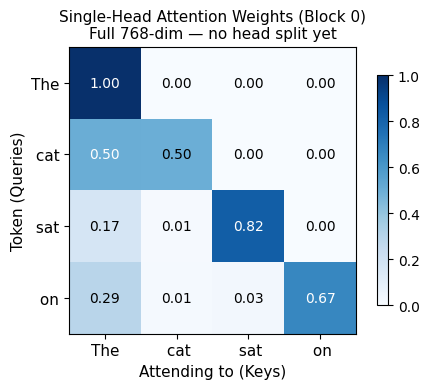

The causal mask creates the triangular pattern — no future tokens visible.


In [8]:
# Visualize attention weights as a heatmap
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

im = ax.imshow(attn_weights, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
ax.set_xticklabels(tokens, fontsize=11)
ax.set_yticklabels(tokens, fontsize=11)
ax.set_xlabel("Attending to (Keys)", fontsize=11)
ax.set_ylabel("Token (Queries)", fontsize=11)
ax.set_title("Single-Head Attention Weights (Block 0)\nFull 768-dim — no head split yet", fontsize=11)

# Annotate cells
for i in range(seq_len):
    for j in range(seq_len):
        val = attn_weights[i, j]
        color = "white" if val > 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10, color=color)

fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print("The causal mask creates the triangular pattern — no future tokens visible.")

## Step 5: Weighted Sum of Values — The Attention Output

The final step: multiply the attention weights by V to get the output.

$$\text{output} = \text{attn\_weights} \times V$$

Each output vector is a **weighted blend** of all the value vectors the token can see.  
A token that pays 80% attention to position 0 and 20% to position 1 gets:  
`output = 0.8 * V[0] + 0.2 * V[1]`

The output has the same shape as the input: `(seq_len, 768)`.  
Each token's representation has now been enriched with information from other tokens.

In [9]:
# Attention output: weighted sum of values
attn_output = attn_weights @ V  # (seq_len, 768)

print(f"Attention output shape: {attn_output.shape}")
print(f"Same shape as input — each token now carries info from other tokens.")
print()

# How much did each token's representation change?
print("How much did attention change each token's representation?")
print(f"(Cosine similarity between V[i] and attention output[i])")
print()
for i, t in enumerate(tokens):
    cos_sim = np.dot(V[i], attn_output[i]) / (np.linalg.norm(V[i]) * np.linalg.norm(attn_output[i]))
    print(f"  {t:>6s}: cosine_sim = {cos_sim:.4f}  ", end="")
    if i == 0:
        print("(only sees itself — output ≈ V[0])")
    else:
        print(f"(blended from {i+1} tokens)")

Attention output shape: (4, 768)
Same shape as input — each token now carries info from other tokens.

How much did attention change each token's representation?
(Cosine similarity between V[i] and attention output[i])

     The: cosine_sim = 1.0000  (only sees itself — output ≈ V[0])
     cat: cosine_sim = 0.7471  (blended from 2 tokens)
     sat: cosine_sim = 0.9832  (blended from 3 tokens)
      on: cosine_sim = 0.9617  (blended from 4 tokens)


## Step 6: Multi-Head Attention — Parallel Perspectives

So far we used the full 768-dim Q, K, V. But GPT-2 actually splits them into **12 heads**,  
each operating on 768/12 = **64 dimensions**.

**Why multiple heads?** Each head can specialize in a different kind of relationship:
- Head 3 might learn subject-verb agreement
- Head 7 might track coreference (which noun does *"it"* refer to?)
- Head 11 might focus on recent context

They run **in parallel** on the same sublayer — not sequentially.

```
Q (seq_len, 768)  ──► split into 12 heads of (seq_len, 64)
K (seq_len, 768)  ──► split into 12 heads of (seq_len, 64)
V (seq_len, 768)  ──► split into 12 heads of (seq_len, 64)
                          │
                   12 parallel attention operations
                          │
                       concatenate
                          │
                   (seq_len, 768)  ──► output projection
```

Total compute is the same as single-head — we just partitioned the dimensions.

In [10]:
n_heads = 12
d_head = 768 // n_heads  # 64

print(f"GPT-2 attention config:")
print(f"  n_heads = {n_heads}")
print(f"  d_head  = {d_head} (768 / 12)")
print(f"  d_k per head = {d_head}  ->  sqrt(d_k) = {np.sqrt(d_head):.1f}")
print()

# Split Q, K, V into heads
# Reshape from (seq_len, 768) to (n_heads, seq_len, 64)
def split_heads(x, n_heads):
    seq_len, d_model = x.shape
    return x.reshape(seq_len, n_heads, d_model // n_heads).transpose(1, 0, 2)

Q_heads = split_heads(Q, n_heads)  # (12, seq_len, 64)
K_heads = split_heads(K, n_heads)  # (12, seq_len, 64)
V_heads = split_heads(V, n_heads)  # (12, seq_len, 64)

print(f"After splitting into heads:")
print(f"  Q_heads shape: {Q_heads.shape}  (n_heads, seq_len, d_head)")
print(f"  K_heads shape: {K_heads.shape}")
print(f"  V_heads shape: {V_heads.shape}")

# Compute attention for all heads
all_attn_weights = []
all_head_outputs = []

for h in range(n_heads):
    # Scaled dot-product attention for this head
    scores_h = Q_heads[h] @ K_heads[h].T / np.sqrt(d_head)  # (seq_len, seq_len)
    scores_h = np.where(causal_mask, -1e9, scores_h)
    weights_h = softmax(scores_h)
    output_h = weights_h @ V_heads[h]  # (seq_len, d_head)
    all_attn_weights.append(weights_h)
    all_head_outputs.append(output_h)

# Concatenate heads back together
# Each head output: (seq_len, 64) -> concat -> (seq_len, 768)
multi_head_output = np.concatenate(all_head_outputs, axis=-1)
print(f"\nConcatenated output: {multi_head_output.shape}")

GPT-2 attention config:
  n_heads = 12
  d_head  = 64 (768 / 12)
  d_k per head = 64  ->  sqrt(d_k) = 8.0

After splitting into heads:
  Q_heads shape: (12, 4, 64)  (n_heads, seq_len, d_head)
  K_heads shape: (12, 4, 64)
  V_heads shape: (12, 4, 64)

Concatenated output: (4, 768)


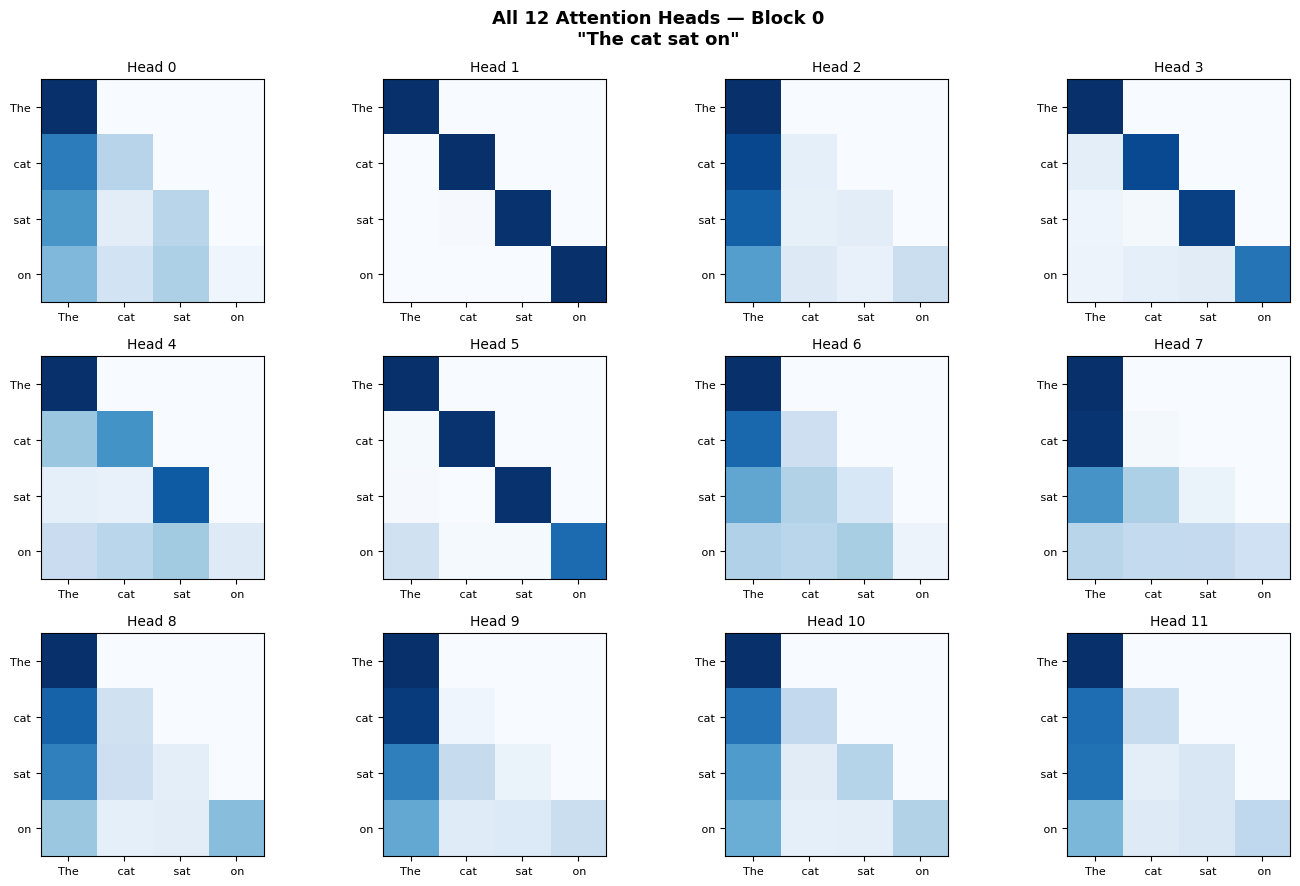

Notice: different heads attend to different positions.
Some heads focus on the immediate previous token.
Others spread attention more broadly.
This diversity is the whole point of multi-head attention.


In [11]:
# Visualize what each head attends to — they look at DIFFERENT things
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle(f"All 12 Attention Heads — Block 0\n\"{text}\"", fontsize=13, fontweight="bold")

for h in range(n_heads):
    ax = axes[h // 4, h % 4]
    im = ax.imshow(all_attn_weights[h], cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels(tokens, fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(f"Head {h}", fontsize=10)

plt.tight_layout()
plt.show()

print("Notice: different heads attend to different positions.")
print("Some heads focus on the immediate previous token.")
print("Others spread attention more broadly.")
print("This diversity is the whole point of multi-head attention.")

## Step 7: Output Projection + Residual Connection

After concatenating the heads, one more linear projection combines them:

$$\text{attn\_out} = \text{concat\_heads} \times W_{\text{proj}} + b_{\text{proj}}$$

Then the result is added back to the original input via a **residual connection**:

$$\text{output} = x + \text{attn\_out}$$

Residual connections solve the vanishing gradient problem — they let information flow  
directly through the network without being forced through every transformation.  
Think of it as a highway lane: the original signal always has a direct path forward.

In [12]:
# Output projection: (seq_len, 768) -> (seq_len, 768)
c_proj_w = weights["h.0.attn.c_proj.weight"]  # (768, 768)
c_proj_b = weights["h.0.attn.c_proj.bias"]    # (768,)

attn_out = multi_head_output @ c_proj_w + c_proj_b  # (seq_len, 768)

# Residual connection: add back the original input
block_output = x + attn_out  # (seq_len, 768)

print(f"Output projection weight: {c_proj_w.shape}")
print(f"Attention output:  {attn_out.shape}")
print(f"After residual:    {block_output.shape}")
print()
print("The residual connection means the output is:")
print("  block_output = original_embedding + attention_contribution")
print()

# How much did attention change the representations?
attn_contribution = np.linalg.norm(attn_out, axis=-1)
original_norm = np.linalg.norm(x, axis=-1)

print("Relative magnitude of attention vs original:")
for i, t in enumerate(tokens):
    ratio = attn_contribution[i] / original_norm[i]
    print(f"  {t:>6s}: ||attn|| / ||x|| = {ratio:.3f}  ", end="")
    bar = '#' * int(ratio * 20)
    print(bar)

Output projection weight: (768, 768)
Attention output:  (4, 768)
After residual:    (4, 768)

The residual connection means the output is:
  block_output = original_embedding + attention_contribution

Relative magnitude of attention vs original:
     The: ||attn|| / ||x|| = 2.186  ###########################################
     cat: ||attn|| / ||x|| = 5.344  ##########################################################################################################
     sat: ||attn|| / ||x|| = 5.227  ########################################################################################################
      on: ||attn|| / ||x|| = 5.590  ###############################################################################################################


## Step 8: The Quadratic Cost — Why Attention Gets Expensive

The attention score matrix $QK^T$ has shape `(seq_len, seq_len)`.  
**This is quadratic in sequence length.** Double the context → 4x the compute and memory.

| Sequence Length | Score Matrix Size | Memory (FP16) |
|:-:|:-:|:-:|
| 1,024 | 1M entries | 2 MB |
| 8,192 | 67M entries | 128 MB |
| 128,000 | 16.4B entries | 31 GB |
| 1,000,000 | 1T entries | 1.9 TB |

This is why long-context models are hard. And this is per-head, per-layer.

**The KV cache saves us during decode:** During autoregressive generation, we don't  
recompute K and V for all previous tokens — we cache them and only compute Q for the  
new token. This makes decode linear rather than quadratic per step.  
But the prefill phase (processing the full input) remains quadratic.

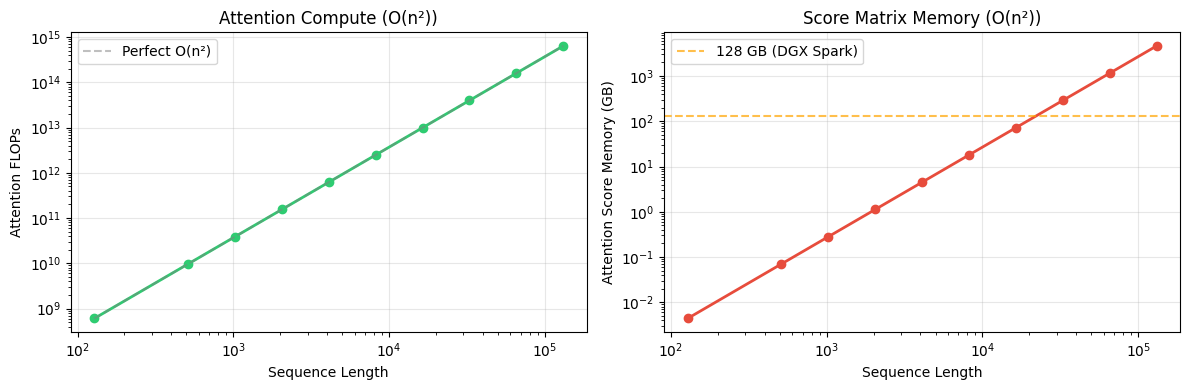

  Seq Length     Attn FLOPs   Score Memory
--------------------------------------------
         128       6.04e+08           4 MB
         512       9.66e+09          72 MB
       1,024       3.87e+10         288 MB
       2,048       1.55e+11         1.1 GB
       4,096       6.18e+11         4.5 GB
       8,192       2.47e+12        18.0 GB
      16,384       9.90e+12        72.0 GB
      32,768       3.96e+13       288.0 GB
      65,536       1.58e+14      1152.0 GB
     131,072       6.33e+14      4608.0 GB


In [13]:
# Show the quadratic scaling visually
seq_lengths = [128, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]

# Compute FLOPs for attention score computation: 2 * seq_len^2 * d_head per head
# Total across all heads and layers for GPT-2 config
n_layers = 12
d_model = 768

attn_flops = []
attn_memory_bytes = []

for s in seq_lengths:
    # QK^T: (s, d_head) @ (d_head, s) = 2 * s * s * d_head per head per layer
    # Weights @ V: (s, s) @ (s, d_head) = 2 * s * s * d_head per head per layer
    flops_per_layer = 2 * n_heads * 2 * s * s * d_head  # QK^T + weights@V
    total_flops = flops_per_layer * n_layers
    attn_flops.append(total_flops)
    
    # Memory for attention scores: s * s * n_heads * n_layers * 2 bytes (FP16)
    mem = s * s * n_heads * n_layers * 2
    attn_memory_bytes.append(mem)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.loglog(seq_lengths, attn_flops, 'o-', color='#2ecc71', linewidth=2, markersize=6)
ax1.set_xlabel("Sequence Length")
ax1.set_ylabel("Attention FLOPs")
ax1.set_title("Attention Compute (O(n\u00b2))")
ax1.grid(True, alpha=0.3)

# Add reference line for perfect quadratic
ref_x = np.array(seq_lengths)
ref_y = ref_x**2 * (attn_flops[0] / seq_lengths[0]**2)
ax1.loglog(ref_x, ref_y, '--', color='gray', alpha=0.5, label='Perfect O(n\u00b2)')
ax1.legend()

ax2.loglog(seq_lengths, [m / (1024**3) for m in attn_memory_bytes], 'o-', color='#e74c3c', linewidth=2, markersize=6)
ax2.set_xlabel("Sequence Length")
ax2.set_ylabel("Attention Score Memory (GB)")
ax2.set_title("Score Matrix Memory (O(n\u00b2))")
ax2.grid(True, alpha=0.3)
ax2.axhline(y=128, color='orange', linestyle='--', alpha=0.7, label='128 GB (DGX Spark)')
ax2.legend()

plt.tight_layout()
plt.show()

# Print a table
print(f"{'Seq Length':>12s} {'Attn FLOPs':>14s} {'Score Memory':>14s}")
print("-" * 44)
for s, f, m in zip(seq_lengths, attn_flops, attn_memory_bytes):
    if m < 1024**2:
        mem_str = f"{m/1024:.0f} KB"
    elif m < 1024**3:
        mem_str = f"{m/1024**2:.0f} MB"
    else:
        mem_str = f"{m/1024**3:.1f} GB"
    print(f"{s:>12,d} {f:>14.2e} {mem_str:>14s}")

## Step 9: Full Single-Head Attention Function

Let's wrap everything into a clean function and run it on a longer sentence  
to see attention patterns that are more interesting.

In [25]:
def multi_head_attention(x, block_idx, weights_dict, n_heads=12):
    """Full multi-head attention for one transformer block.
    
    x: (seq_len, 768) — input embeddings
    block_idx: which transformer block (0-11)
    returns: (seq_len, 768) — residual-added output, attention weights per head
    """
    prefix = f"h.{block_idx}"
    seq_len, d_model = x.shape
    d_head = d_model // n_heads
    
    # Layer norm
    ln_g = weights_dict[f"{prefix}.ln_1.weight"]
    ln_b = weights_dict[f"{prefix}.ln_1.bias"]
    x_norm = layer_norm(x, ln_g, ln_b)
    
    # Q, K, V projection
    qkv = x_norm @ weights_dict[f"{prefix}.attn.c_attn.weight"] + weights_dict[f"{prefix}.attn.c_attn.bias"]
    Q, K, V = np.split(qkv, 3, axis=-1)
    
    # Split into heads
    Q_h = Q.reshape(seq_len, n_heads, d_head).transpose(1, 0, 2)
    K_h = K.reshape(seq_len, n_heads, d_head).transpose(1, 0, 2)
    V_h = V.reshape(seq_len, n_heads, d_head).transpose(1, 0, 2)
    
    # Causal mask
    mask = np.triu(np.ones((seq_len, seq_len), dtype=bool), k=1)
    
    # Attention per head
    head_outputs = []
    head_weights = []
    for h in range(n_heads):
        scores = Q_h[h] @ K_h[h].T / np.sqrt(d_head)
        scores = np.where(mask, -1e9, scores)
        w = softmax(scores)
        head_weights.append(w)
        head_outputs.append(w @ V_h[h])
    
    # Concatenate + output projection
    concat = np.concatenate(head_outputs, axis=-1)
    out = concat @ weights_dict[f"{prefix}.attn.c_proj.weight"] + weights_dict[f"{prefix}.attn.c_proj.bias"]
    
    return x + out, head_weights


# Run on a more interesting sentence
text2 = "The cat sat on the mat because it was tired"
ids2 = encode(text2)
tokens2 = [decode([i]) for i in ids2]
x2 = embed(ids2)

output2, head_weights2 = multi_head_attention(x2, block_idx=0, weights_dict=weights)

print(f"Input: '{text2}'")
print(f"Tokens: {tokens2}")
print(f"Output shape: {output2.shape}")
print()

# Find which head pays most attention from "it" to "cat"
it_idx = tokens2.index(" it")
cat_idx = tokens2.index(" cat")
print(f"Which heads connect 'it' (pos {it_idx}) back to 'cat' (pos {cat_idx})?")
print()
for h in range(12):
    w = head_weights2[h][it_idx, cat_idx]
    bar = '#' * int(w * 50)
    print(f"  Head {h:>2d}: {w:.4f} {bar}")

Input: 'The cat sat on the mat because it was tired'
Tokens: ['The', ' cat', ' sat', ' on', ' the', ' mat', ' because', ' it', ' was', ' tired']
Output shape: (10, 768)

Which heads connect 'it' (pos 7) back to 'cat' (pos 1)?

  Head  0: 0.1458 #######
  Head  1: 0.0033 
  Head  2: 0.0673 ###
  Head  3: 0.0008 
  Head  4: 0.0388 #
  Head  5: 0.0322 #
  Head  6: 0.2363 ###########
  Head  7: 0.0157 
  Head  8: 0.0142 
  Head  9: 0.0739 ###
  Head 10: 0.0612 ###
  Head 11: 0.0738 ###


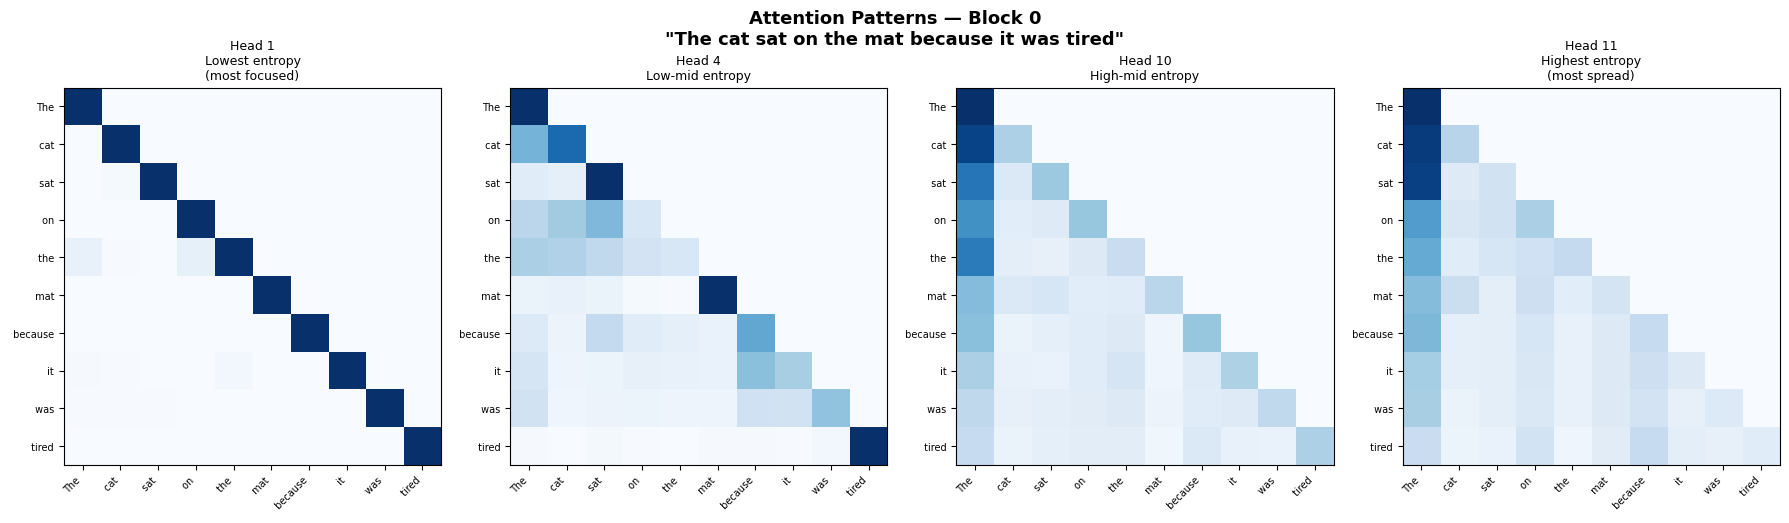

Focused heads (low entropy) tend to look at one specific position — often the previous token.
Spread heads (high entropy) distribute attention broadly — they aggregate context.


In [26]:
# Visualize the most interesting heads for the longer sentence
# Find the 4 heads with highest entropy (most distributed attention)
entropies = []
for h in range(12):
    w = head_weights2[h]
    # Average entropy across all query positions
    entropy = -np.sum(w * np.log(w + 1e-10), axis=-1).mean()
    entropies.append(entropy)

# Pick 4 diverse heads: highest entropy, lowest entropy, and two middle ones
sorted_heads = np.argsort(entropies)
interesting = [sorted_heads[0], sorted_heads[3], sorted_heads[8], sorted_heads[11]]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f"Attention Patterns — Block 0\n\"{text2}\"", fontsize=13, fontweight="bold")

labels = ["Lowest entropy\n(most focused)", "Low-mid entropy", "High-mid entropy", "Highest entropy\n(most spread)"]

for idx, (h, label) in enumerate(zip(interesting, labels)):
    ax = axes[idx]
    im = ax.imshow(head_weights2[h], cmap="Blues", vmin=0, vmax=0.8)
    ax.set_xticks(range(len(tokens2)))
    ax.set_yticks(range(len(tokens2)))
    ax.set_xticklabels(tokens2, fontsize=7, rotation=45, ha="right")
    ax.set_yticklabels(tokens2, fontsize=7)
    ax.set_title(f"Head {h}\n{label}", fontsize=9)

plt.tight_layout()
plt.show()

print("Focused heads (low entropy) tend to look at one specific position — often the previous token.")
print("Spread heads (high entropy) distribute attention broadly — they aggregate context.")

## Step 10: Attention Across Layers — How Patterns Evolve

Block 0 sees raw embeddings. Block 11 sees highly processed representations.  
Let's run attention through multiple blocks and see how the patterns change.

### But First: What Does the MLP (Feed-Forward Network) Do?

To run through all 12 blocks, we need both sublayers: attention *and* the MLP.  
We've covered attention in depth. Here's the MLP — explained in DevOps terms.

**Attention** answers: *"Which other tokens should I blend information from?"*  
**MLP** answers: *"Now that I've gathered context, what does it actually mean?"*

Example: *"The bank was covered in moss."*
1. **Attention** connects "bank" to "moss" and "covered" — gathering clues from surrounding words.
2. **MLP** takes those clues and makes the decision: "bank" means *riverbank*, not *financial bank*.

Attention is the **listening** step. MLP is the **thinking** step.

---

The MLP has three stages:

```
768 dims ──► expand to 3072 ──► GELU activation ──► compress back to 768
```

**Expand (768 → 3072)** — *Create derived metrics*  
You have a server with 768 metrics: CPU, memory, disk, network, etc.  
Some issues only show up as **combinations**: high CPU *and* high disk I/O together means  
something different than either alone. Expanding to 3072 is like creating derived metrics in  
your monitoring dashboard — each of the 3072 outputs is a weighted mix of all 768 inputs.  
More dimensions = more room to separate situations that look similar in the compressed view.

**GELU activation** — *Apply alert thresholds*  
Now you have 3072 derived metrics. GELU decides which signals matter and which are noise:

- If the signal is strongly positive → pass it through (alert fires)
- If the signal is strongly negative → squash to ~0 (suppress)
- If the signal is near zero → smooth transition (borderline, scale down)

**Why this matters:** Without GELU, expand + compress is two matrix multiplies back to back —  
which mathematically collapses into a single matrix multiply. You gain nothing from stacking layers.  
It's like the difference between 12 identical load balancers in series (pointless) vs 12 stages of  
a CI/CD pipeline where each stage makes a pass/fail decision (useful).  
The nonlinearity is what makes depth useful.

**Compress (3072 → 768)** — *Summarize back to incident format*  
3072 alert evaluations get distilled back into a 768-field record.  
Same shape in, same shape out — so the next transformer block can consume it  
without knowing what happened inside this one. Like PagerDuty condensing  
thousands of alert evaluations into one incident record.

```
Raw metrics (768)
    │
    ▼
Create derived metrics / feature crosses (3072)    ← EXPAND
    │
    ▼
Apply alert thresholds — fire or suppress (3072)   ← GELU
    │
    ▼
Summarize back to incident format (768)            ← COMPRESS
```

The MLP is where the model's **knowledge** lives. Attention weights are ~1/3 of parameters;  
MLP weights are ~2/3. When people say a model "knows" that Paris is the capital of France,  
that fact is stored somewhere in these MLP layers.

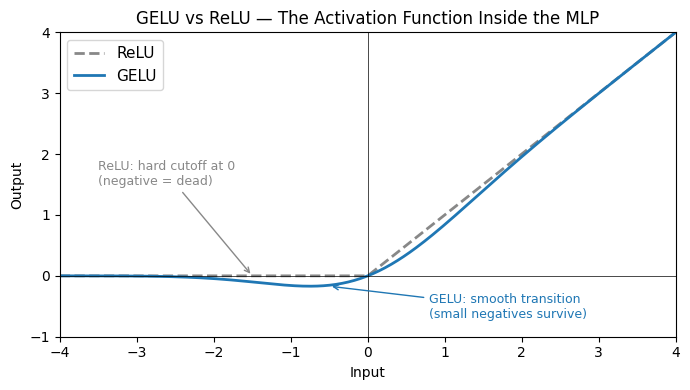

ReLU: if input < 0, output = 0. Hard gate. Dead neurons possible.
GELU: smooth curve. Near-zero inputs get scaled down gently, not killed.
      That small dip below zero (around x ≈ -0.5) preserves information ReLU destroys.

Why it matters: without a nonlinearity between the two linear layers,
expand (768→3072) + compress (3072→768) collapses into one matrix multiply.
GELU is what makes stacking layers actually increase the model's capacity.


In [27]:
# Visualize GELU vs ReLU — see the difference before we use it
x = np.linspace(-4, 4, 300)

relu = np.maximum(0, x)
gelu_y = 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, relu, label="ReLU", linewidth=2, linestyle="--", color="#888")
ax.plot(x, gelu_y, label="GELU", linewidth=2, color="#1f77b4")
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlim(-4, 4)
ax.set_ylim(-1, 4)
ax.set_xlabel("Input")
ax.set_ylabel("Output")
ax.set_title("GELU vs ReLU — The Activation Function Inside the MLP")
ax.legend(fontsize=11)
ax.annotate("ReLU: hard cutoff at 0\n(negative = dead)",
            xy=(-1.5, 0), xytext=(-3.5, 1.5),
            arrowprops=dict(arrowstyle="->", color="#888"), fontsize=9, color="#888")
ax.annotate("GELU: smooth transition\n(small negatives survive)",
            xy=(-0.5, -0.17), xytext=(0.8, -0.7),
            arrowprops=dict(arrowstyle="->", color="#1f77b4"), fontsize=9, color="#1f77b4")
plt.tight_layout()
plt.show()

print("ReLU: if input < 0, output = 0. Hard gate. Dead neurons possible.")
print("GELU: smooth curve. Near-zero inputs get scaled down gently, not killed.")
print("      That small dip below zero (around x ≈ -0.5) preserves information ReLU destroys.")
print()
print("Why it matters: without a nonlinearity between the two linear layers,")
print("expand (768→3072) + compress (3072→768) collapses into one matrix multiply.")
print("GELU is what makes stacking layers actually increase the model's capacity.")

In [28]:
# To run through multiple blocks, we also need the MLP (feed-forward) sublayer.
# Let's implement a complete transformer block.

def gelu(x):
    """GELU activation — the smooth ReLU used in GPT-2."""
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

def feed_forward(x, block_idx, weights_dict):
    """MLP sublayer: expand to 4x, apply GELU, project back."""
    prefix = f"h.{block_idx}"
    ln_g = weights_dict[f"{prefix}.ln_2.weight"]
    ln_b = weights_dict[f"{prefix}.ln_2.bias"]
    x_norm = layer_norm(x, ln_g, ln_b)
    
    # Up-project: 768 -> 3072 (4x expansion)
    h = x_norm @ weights_dict[f"{prefix}.mlp.c_fc.weight"] + weights_dict[f"{prefix}.mlp.c_fc.bias"]
    h = gelu(h)
    # Down-project: 3072 -> 768
    h = h @ weights_dict[f"{prefix}.mlp.c_proj.weight"] + weights_dict[f"{prefix}.mlp.c_proj.bias"]
    return x + h  # residual

def transformer_block(x, block_idx, weights_dict):
    """One complete transformer block: attention + MLP."""
    x, attn_w = multi_head_attention(x, block_idx, weights_dict)
    x = feed_forward(x, block_idx, weights_dict)
    return x, attn_w

# Run through all 12 blocks, collecting attention from layers 0, 3, 7, 11
x_running = embed(ids2)
layer_attn = {}

for layer in range(12):
    x_running, attn_w = transformer_block(x_running, layer, weights)
    if layer in [0, 3, 7, 11]:
        layer_attn[layer] = attn_w

print(f"Ran all 12 transformer blocks.")
print(f"Final output shape: {x_running.shape}")
print()

# Compare how "it" attends across layers (average across heads)
print(f"Where does 'it' (pos {it_idx}) look across layers? (head-averaged attention)")
print(f"{'':>10s}", end="")
for t in tokens2:
    print(f"{t:>7s}", end="")
print()
for layer_idx in [0, 3, 7, 11]:
    avg_w = np.mean([layer_attn[layer_idx][h][it_idx] for h in range(12)], axis=0)
    print(f"Layer {layer_idx:>2d}:", end="")
    for w in avg_w:
        print(f"{w:>7.3f}", end="")
    print()

Ran all 12 transformer blocks.
Final output shape: (10, 768)

Where does 'it' (pos 7) look across layers? (head-averaged attention)
              The    cat    sat     on    the    mat because     it    was  tired
Layer  0:  0.173  0.064  0.062  0.066  0.083  0.074  0.133  0.346  0.000  0.000
Layer  3:  0.559  0.033  0.014  0.010  0.019  0.020  0.258  0.087  0.000  0.000
Layer  7:  0.708  0.024  0.030  0.040  0.016  0.033  0.103  0.045  0.000  0.000
Layer 11:  0.666  0.057  0.066  0.022  0.017  0.044  0.053  0.074  0.000  0.000


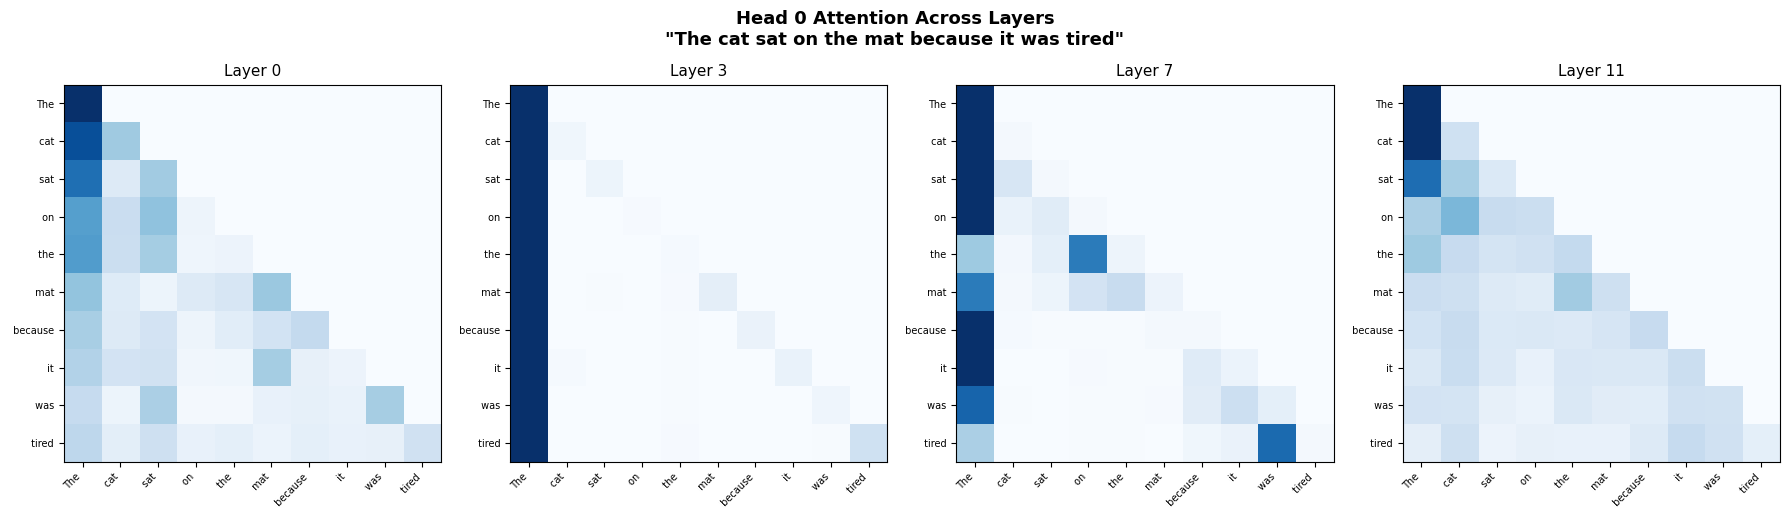

Early layers (0, 3): attention patterns are simple — nearby tokens, positional bias.
Later layers (7, 11): attention becomes more semantic — looking at contextually relevant tokens.


In [29]:
# Visualize attention evolution: head 0 across layers 0, 3, 7, 11
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f"Head 0 Attention Across Layers\n\"{text2}\"", fontsize=13, fontweight="bold")

for idx, layer_idx in enumerate([0, 3, 7, 11]):
    ax = axes[idx]
    im = ax.imshow(layer_attn[layer_idx][0], cmap="Blues", vmin=0, vmax=0.8)
    ax.set_xticks(range(len(tokens2)))
    ax.set_yticks(range(len(tokens2)))
    ax.set_xticklabels(tokens2, fontsize=7, rotation=45, ha="right")
    ax.set_yticklabels(tokens2, fontsize=7)
    ax.set_title(f"Layer {layer_idx}", fontsize=11)

plt.tight_layout()
plt.show()

print("Early layers (0, 3): attention patterns are simple — nearby tokens, positional bias.")
print("Later layers (7, 11): attention becomes more semantic — looking at contextually relevant tokens.")

## Experiments: Try These

**1. Change the sentence and watch attention shift**  
Replace `text2` with a sentence that has a clear pronoun reference, like:  
*"The dog chased the ball because it was excited"*  
Does any head connect *"it"* to *"dog"* instead of *"ball"*?

> **What we found:** GPT-2 doesn't clearly resolve this. Across all 12 layers, *"it"* mostly
> attends to *"The"* (the first token) — 55–70% of attention weight by the middle layers.
> *"dog"* only receives 2–8%, barely more than *"ball"* or *"chased"*.
>
> This is the **BOS attention sink** — a known pattern in small autoregressive models where
> the first token acts as a default target, absorbing attention that has nowhere better to go.
> The first token becomes a "garbage collector" for unfocused attention.
>
> **Why?** Coreference resolution (*"it"* = *"dog"*) is a hard semantic task. GPT-2 has
> only 12 layers and 124M parameters — it relies on positional heuristics more than
> deep semantic understanding. Larger models (Llama 70B, GPT-4) show much clearer
> coreference signals in their attention heads because they have the depth and capacity
> to build those representations.
>
> **Inference takeaway:** This is one reason scaling matters. The attention *mechanism* is
> identical across model sizes — the difference is whether the learned weights are rich
> enough to use it for semantic reasoning vs. falling back on positional shortcuts.

**2. Compare attention at different layers for a longer prompt**  
Use a 50+ token input. Do later layers show more long-range connections?  
Compute the average attention distance per head: `sum(weight[i,j] * |i-j|)` for each head.

**3. Build a KV cache simulator**  
During autoregressive decode, we only compute Q for the new token and reuse cached K, V.  
Modify `multi_head_attention` to accept a `kv_cache` parameter. Compare the FLOPs of  
recomputing full attention vs using the cache for a 100-token decode sequence.  
This is the core idea behind the KV cache optimization covered in Day 14.


## Beyond GPT-2: How Modern LLMs Compute Attention

GPT-2 uses the original **Multi-Head Attention (MHA)** — every head has its own Q, K, and V projections.  
Modern LLMs have changed *how Q, K, V are organized across heads* to reduce memory during inference.

The core equation is the same everywhere:

$$\text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

### The three main attention variants

| Variant | Q heads | K heads | V heads | KV cache size | Used by |
|---------|---------|---------|---------|---------------|---------|
| **MHA** (Multi-Head) | N | N | N | 1x (baseline) | GPT-2, GPT-3 |
| **MQA** (Multi-Query) | N | 1 | 1 | 1/N of MHA | PaLM, Falcon |
| **GQA** (Grouped-Query) | N | G | G | G/N of MHA | Llama 2/3, Mistral, Gemma |

```
MHA:   Q1->K1  Q2->K2  Q3->K3  Q4->K4     (every head has its own K,V)
MQA:   Q1->K1  Q2->K1  Q3->K1  Q4->K1     (all heads share one K,V)
GQA:   Q1->K1  Q2->K1  Q3->K2  Q4->K2     (heads share K,V in groups)
```

**Why this matters for inference:** During autoregressive generation, you cache K and V for every past token  
(the **KV cache**). With MHA, that's `2 x n_layers x n_heads x d_head x seq_len` of memory.  
GQA/MQA shrink this dramatically — Llama 3 70B with GQA uses 8 KV heads instead of 64, cutting KV cache by 8x.

### Other differences across model families

| Feature | GPT-2 (this notebook) | Modern LLMs (Llama, Mistral) |
|---------|----------------------|------------------------------|
| **Positional encoding** | Learned absolute (`wpe`) | RoPE (rotary, applied to Q/K) |
| **LayerNorm placement** | Post-norm | Pre-norm (+ RMSNorm instead of LayerNorm) |
| **MLP activation** | GELU | SwiGLU (gated, slightly larger MLP) |
| **Bias terms** | Yes (`c_attn.bias`, `c_proj.bias`) | No (most modern models drop biases) |
| **Fused QKV** | Yes (`c_attn` = one matrix) | Separate Q, K, V projections (different sizes with GQA) |

The core idea — tokens attending to other tokens via learned projections — hasn't changed  
since the 2017 *"Attention Is All You Need"* paper. The engineering has evolved to make it  
cheaper at inference time, especially for long sequences.

## Key Takeaways

- **Attention lets tokens communicate.** Without it, each token would be processed in isolation. The attention equation $\text{softmax}(QK^T/\sqrt{d_k})V$ is a learned, weighted lookup.
- **The causal mask makes LLMs autoregressive.** Token $i$ can only attend to positions $\leq i$. This is enforced by setting future positions to $-\infty$ before softmax.
- **Multi-head attention provides parallel perspectives.** GPT-2's 12 heads each use 64 dimensions. Different heads specialize in different types of relationships.
- **Attention is quadratic in sequence length** — $O(n^2)$ in both compute and memory. This is the fundamental bottleneck for long-context inference, and why optimizations like FlashAttention and KV caching exist.
- **Next:** Day 05 covers Ops:Byte Ratio & Arithmetic Intensity — the framework for understanding *when* attention (and other operations) are compute-bound vs memory-bound.

## References

- *Inference Engineering* Ch 2.2.2–2.2.3 (pp. 50–53) — Transformer blocks, attention mechanism
- Vaswani et al., "Attention Is All You Need" (2017) — Original transformer architecture
- Dao et al., "FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness" (2022) — Referenced in Book Figure 2.8